

---

##  Overview

In this assignment, you will build, train, and evaluate Convolutional Neural Networks (CNNs) using the **CIFAR-10** dataset — a well-known benchmark dataset containing **60,000 color images** across **10 classes** (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

- **Image size:** 32×32 pixels, 3 channels (RGB)
- **Training set:** 50,000 images
- **Test set:** 10,000 images
- **Classes:** 10 balanced classes (6,000 images per class)

CIFAR-10 is ideal for this assignment: it is small enough to train on a CPU/free GPU (Google Colab), yet complex enough to make architectural choices meaningful.

---

##  Learning Objectives

By completing this assignment, you will be able to:
1. Understand and implement convolutional layers, pooling, and filters
2. Apply data augmentation to improve model generalization
3. Build and compare different CNN architectures
4. Evaluate models using appropriate metrics

---




In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


### Load the Dataset

Load the CIFAR-10 training and test sets using `torchvision.datasets.CIFAR10`.

Create DataLoaders with:
- `batch_size = 64`
- `shuffle=True` for train, `shuffle=False` for test

Using device: cpu


100%|██████████| 170M/170M [00:06<00:00, 24.8MB/s]


Number of training samples: 50000
Number of test samples: 10000
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: torch.Size([3, 32, 32])


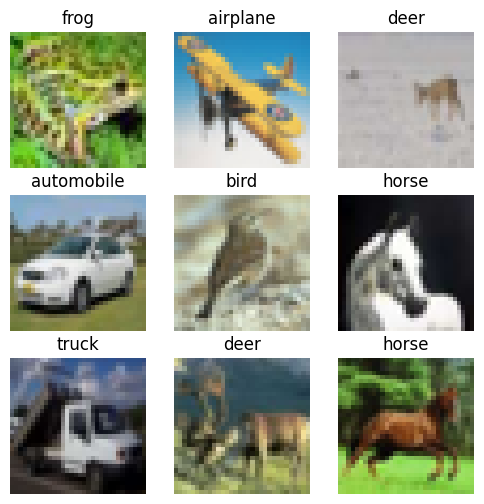

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Step 2: Define Transformations (ToTensor + Normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Step 3: Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                             train=True,
                                             download=True,
                                             transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                            train=False,
                                            download=True,
                                            transform=transform)

# Step 4: Create DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Step 5: Print dataset info
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))
print("Class names:", train_dataset.classes)
print("Image shape:", train_dataset[0][0].shape)  # (Channels, Height, Width)

# Step 6: Visualize 9 sample images
classes = train_dataset.classes
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i] / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))  # C,H,W -> H,W,C
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_Model1(nn.Module):
    def __init__(self):
        super(CNN_Model1, self).__init__()
        # Convolutional layer 1: input 3 channels, output 32 channels, 3x3 kernel
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # Convolutional layer 2: input 32 channels, output 64 channels, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)  # 32x32 -> pool -> 16x16 -> pool -> 8x8
        self.fc2 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)          # 32x32 -> 16x16
        x = F.relu(self.conv2(x))
        x = self.pool(x)          # 16x16 -> 8x8
        x = x.view(-1, 64 * 8 * 8)  # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model and move to device
model1 = CNN_Model1().to(device)
print(model1)

CNN_Model1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Use smaller CNN for faster training
class CNN_Model1(nn.Module):
    def __init__(self):
        super(CNN_Model1, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)  # fewer filters
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*8*8, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)       # 32x32 -> 16x16
        x = F.relu(self.conv2(x))
        x = self.pool(x)       # 16x16 -> 8x8
        x = x.view(-1, 32*8*8) # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model
model1 = CNN_Model1().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

# Use smaller batch size and fewer epochs for testing
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

epochs = 2  # start small to test speed

# Training loop
for epoch in range(epochs):
    model1.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluate
model1.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model1(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")

Epoch 1/2, Loss: 1.3899
Epoch 2/2, Loss: 1.0407
Test Accuracy: 63.84%


In [7]:
model1.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model1(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 63.84%


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ---------------------------
# 1. Load Dataset (FAST SUBSET)
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# 🔥 SMALL SUBSET (VERY IMPORTANT)
train_subset = Subset(train_dataset, range(2000))
test_subset = Subset(test_dataset, range(500))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

# ---------------------------
# 2. Define Models
# ---------------------------

class CNN_Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(128*4*4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128*4*4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class CNN_Model3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 32*16*16)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class CNN_Model4(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = x.view(-1, 32*16*16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ---------------------------
# 3. Train Function (FAST)
# ---------------------------

def train_model(model):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 1  # 🔥 VERY FAST

    for epoch in range(epochs):
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            if i % 50 == 0:
                print(f"Batch {i}")

        print("Epoch done")

# ---------------------------
# 4. Evaluate Function
# ---------------------------

def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")
    return acc

# ---------------------------
# 5. Run Models
# ---------------------------

results = []

print("\nModel 2")
model2 = CNN_Model2()
train_model(model2)
acc2 = evaluate_model(model2)
results.append(("Model 2", acc2))

print("\nModel 3")
model3 = CNN_Model3()
train_model(model3)
acc3 = evaluate_model(model3)
results.append(("Model 3", acc3))

print("\nModel 4")
model4 = CNN_Model4()
train_model(model4)
acc4 = evaluate_model(model4)
results.append(("Model 4", acc4))

# ---------------------------
# 6. Results
# ---------------------------

print("\nFinal Results:")
for name, acc in results:
    print(f"{name}: {acc:.2f}%")

Using device: cpu

Model 2
Batch 0
Batch 50
Epoch done
Accuracy: 24.00%

Model 3
Batch 0
Batch 50
Epoch done
Accuracy: 29.60%

Model 4
Batch 0
Batch 50
Epoch done
Accuracy: 32.00%

Final Results:
Model 2: 24.00%
Model 3: 29.60%
Model 4: 32.00%


In [17]:
import torch.nn as nn
import torch.nn.functional as F

# Model with Max Pooling
class CNN_MaxPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)   # Max Pooling
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 32*16*16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model with Average Pooling
class CNN_AvgPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.AvgPool2d(2,2)   # Average Pooling
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 32*16*16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [18]:
# Function to train model (reuse previous train_model)
def train_model_pool(model):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    epochs = 1  # fast for subset
    for epoch in range(epochs):
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} done")

# Function to evaluate
def evaluate_model_pool(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")
    return acc

# Run Max Pooling Model
print("Training Max Pooling Model")
max_pool_model = CNN_MaxPool()
train_model_pool(max_pool_model)
max_acc = evaluate_model_pool(max_pool_model)

# Run Average Pooling Model
print("\nTraining Average Pooling Model")
avg_pool_model = CNN_AvgPool()
train_model_pool(avg_pool_model)
avg_acc = evaluate_model_pool(avg_pool_model)

Training Max Pooling Model
Epoch 1 done
Accuracy: 31.00%

Training Average Pooling Model
Epoch 1 done
Accuracy: 29.40%


In [19]:
def train_model_history(model, epochs=1):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    train_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss/len(train_loader))
        train_accs.append(100 * correct/total)
        print(f"Epoch {epoch+1} done: Loss={train_losses[-1]:.4f}, Acc={train_accs[-1]:.2f}%")

    return train_losses, train_accs

In [20]:
# Example with Model 2
model2 = CNN_Model2()
loss_history, acc_history = train_model_history(model2, epochs=5)

Epoch 1 done: Loss=2.1126, Acc=21.20%
Epoch 2 done: Loss=1.8061, Acc=34.45%
Epoch 3 done: Loss=1.6351, Acc=40.05%
Epoch 4 done: Loss=1.4724, Acc=45.50%
Epoch 5 done: Loss=1.3372, Acc=49.40%


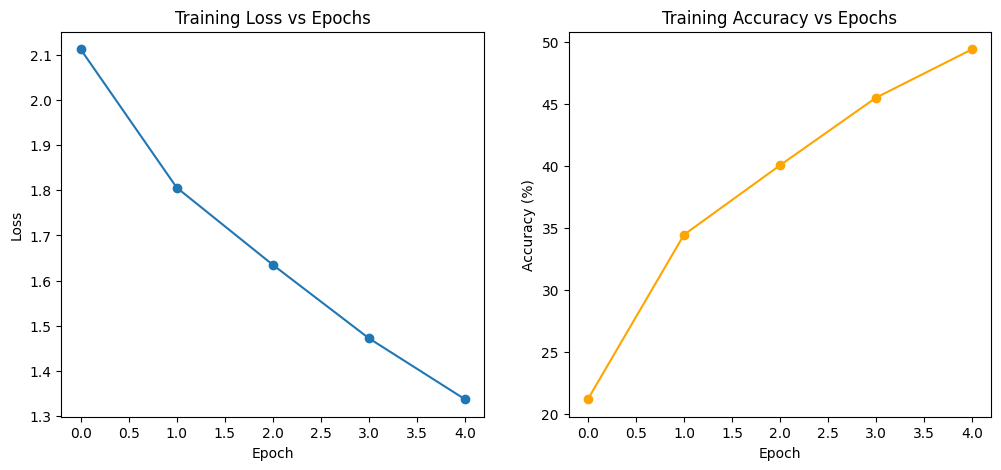

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(loss_history, marker='o')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy
plt.subplot(1,2,2)
plt.plot(acc_history, marker='o', color='orange')
plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()

###  Reflection Question

Answer the following questions in the Markdown cell below:

1. What do you observe in the learned filters? Can you identify any patterns (e.g., edge detectors, color detectors)?






2. How does **Max Pooling** differ from **Average Pooling**? When might you prefer one over the other?




3. If you increase the number of filters in a conv layer, how does that affect the number of trainable parameters?




**Your Answer:**

1.


- In the first convolutional layer, the filters often learn to detect **edges, corners, and simple color patterns**.  
- Early layers capture **basic visual features** like horizontal, vertical, and diagonal edges.  
- Deeper layers tend to combine these simple patterns into more **complex textures or shapes** that help distinguish classes.  
- Some filters respond strongly to specific colors, so **color detection** is also visible in certain filters.

2. - **Max Pooling:** selects the maximum value in each pooling window.  
  - Preserves **strongest features** like edges and prominent textures.  
  - Often leads to **better performance in image classification** because it keeps key details.  
- **Average Pooling:** computes the average value in each pooling window.  
  - Smooths the feature map, which can remove noise but may also **blur important details**.  
- **When to prefer:**  
  - Max Pooling → most CNNs for classification tasks  
  - Average Pooling → when you want a **more generalized or smoothed representation**, e.g., in some segmentation or autoencoder tasks.



3. -

 Increasing the number of filters **directly increases the number of trainable parameters**, because each filter has its own weights and biases.  
- More filters → more capacity to learn complex features → **higher accuracy potential**, but also:  
  - More computation  
  - Higher memory usage  
  - Greater risk of overfitting if dataset is small
